<a href="https://colab.research.google.com/github/PatrickPasolini/water_potability_classification/blob/main/water_potability_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Water Potability
link dataset : https://raw.githubusercontent.com/PatrickPasolini/water_potability_classification/refs/heads/main/data/water_potability.csv


##Import

In [89]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, f1_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_score, train_test_split, RandomizedSearchCV)

## Data

In [90]:
DATA_PATH = "https://raw.githubusercontent.com/PatrickPasolini/water_potability_classification/refs/heads/main/data/water_potability.csv"
OUTPUT_PATH = ""
RANDOM_STATE = 3993
TRAIN_SIZE = 0.8



In [91]:
df = pd.read_csv(DATA_PATH)

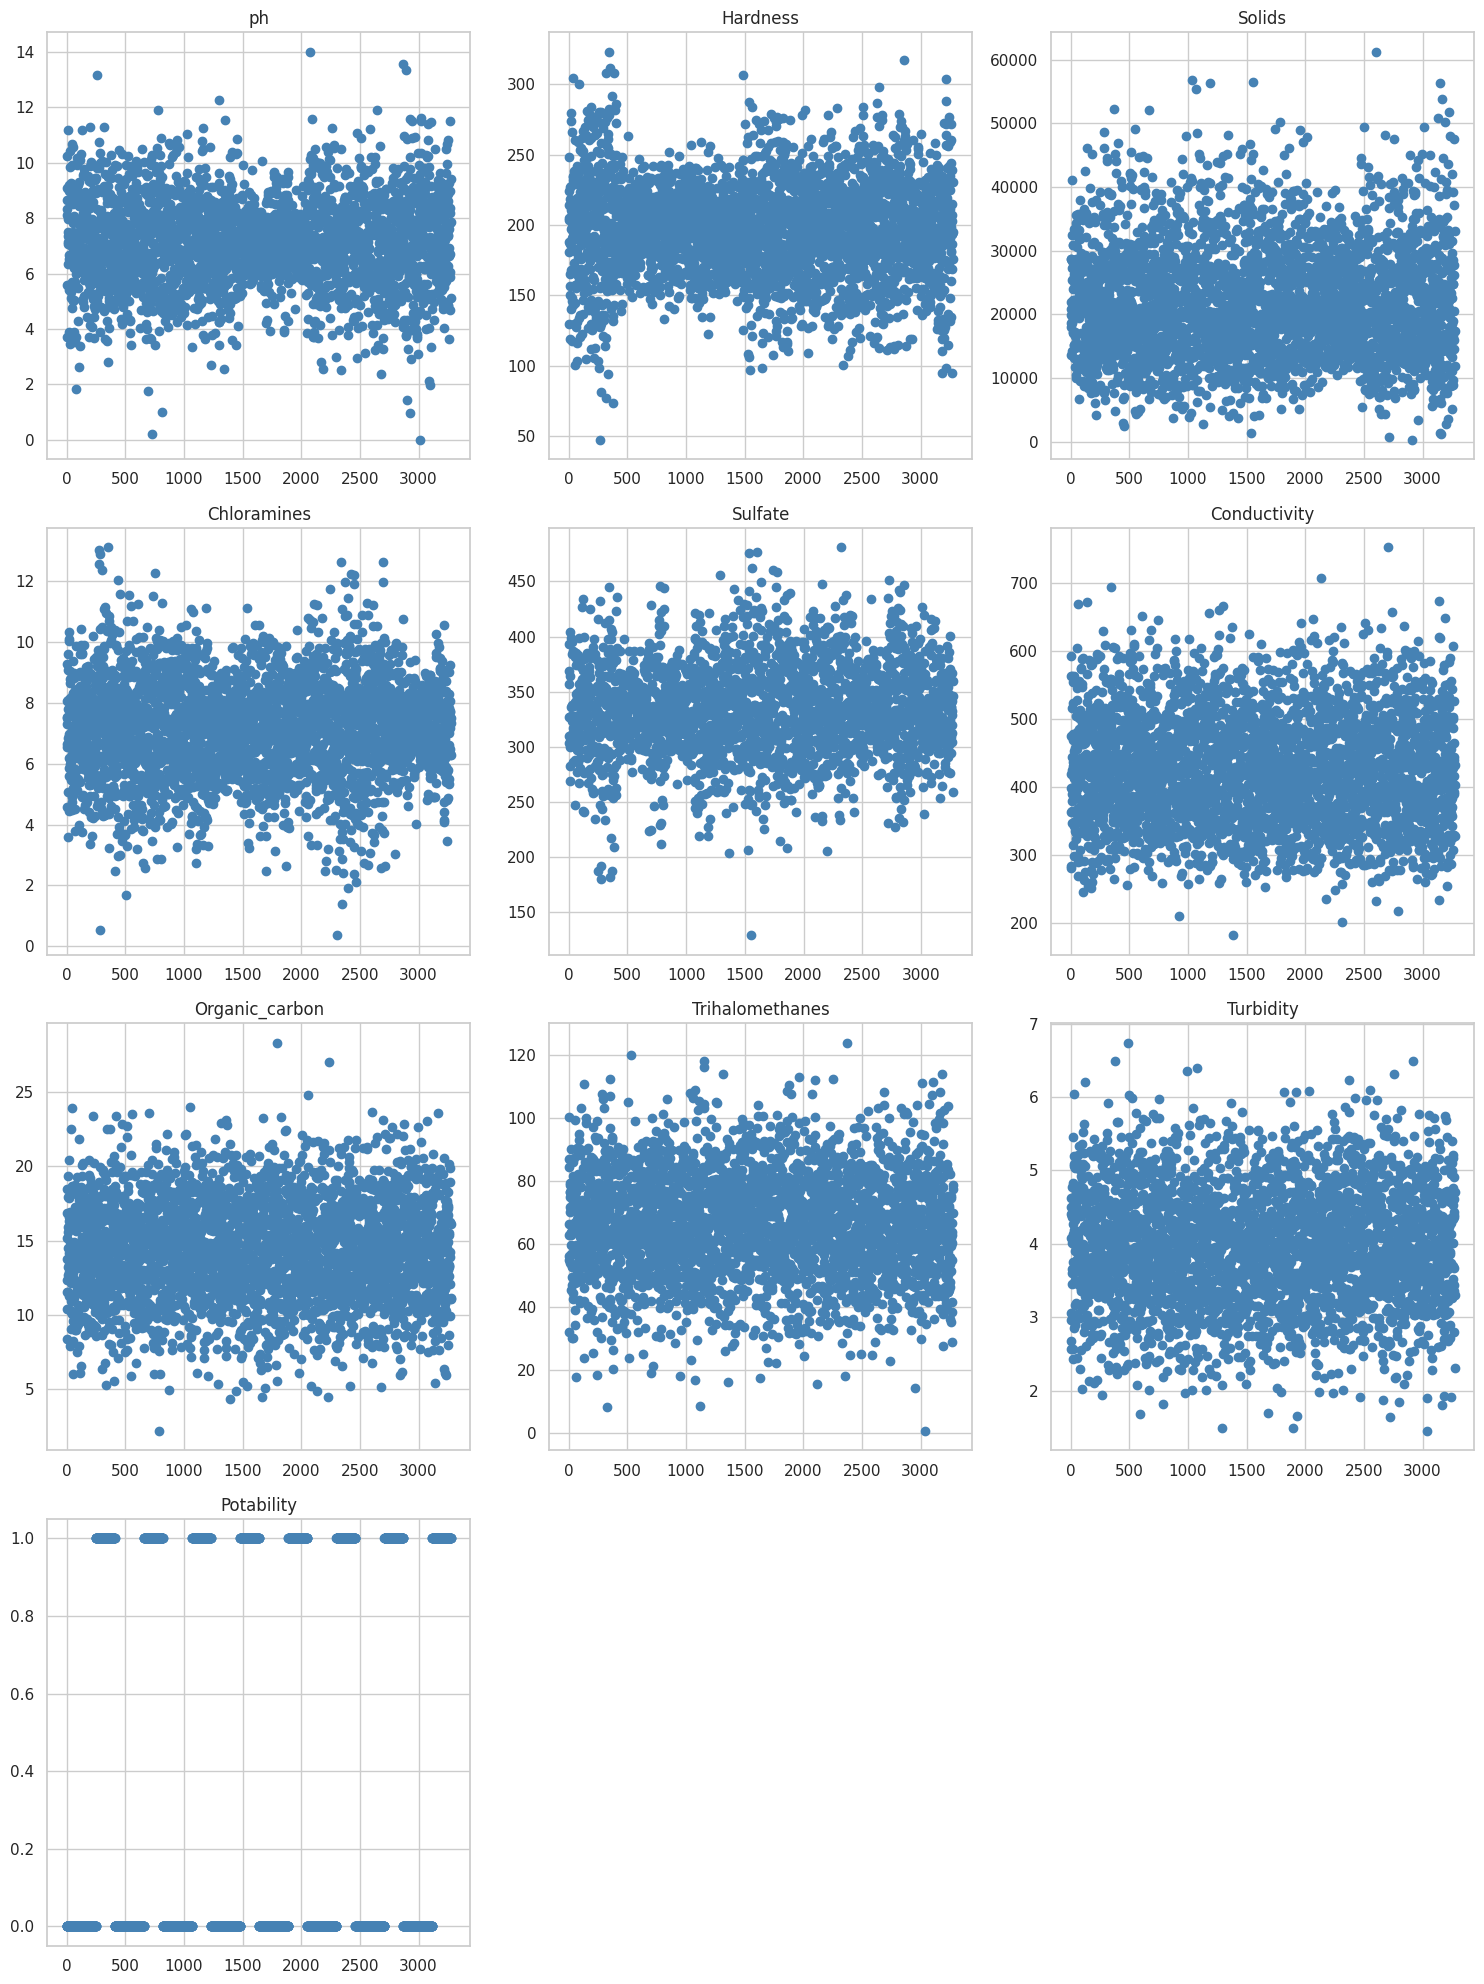

In [92]:

# Get a list of all attributes (column names) in the DataFrame
attributes = df.columns.tolist()

# Calculate the number of rows and columns for subplots
num_plots = len(attributes)
num_cols = 3  # Number of columns in the subplot grid
num_rows = (num_plots + num_cols - 1) // num_cols

# Set up the figure and subplots
fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 5*num_rows))
axs = axs.flatten()  # Flatten the array of subplots

# Generate scatter plots for each attribute
for i, attribute in enumerate(attributes):
    ax = axs[i]  # Select the appropriate subplot
    ax.scatter(df.index, df[attribute])  # Generate the scatter plot
    ax.set_title(attribute)  # Set the subplot title


# nasconde eventuali subplot vuoti (es. con 10 feature su griglia 4x3)
for j in range(len(attributes), len(axs)):
    axs[j].set_visible(False)

# Adjust subplot spacing and display the plot
plt.tight_layout()
#plt.savefig('raw_datas_scatter.png', dpi=300)
plt.show()

### Gestione dei missing values

In [93]:
df.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


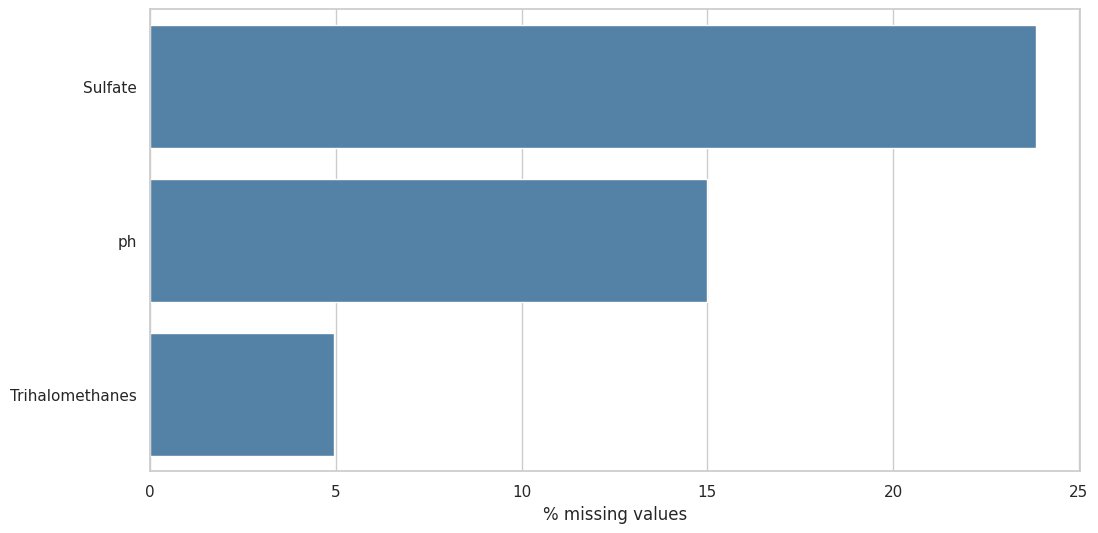

In [94]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = missing / len(df) * 100

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_pct.values, y=missing_pct.index)
plt.xlabel("% missing values")
plt.ylabel("")
plt.show()

<Axes: >

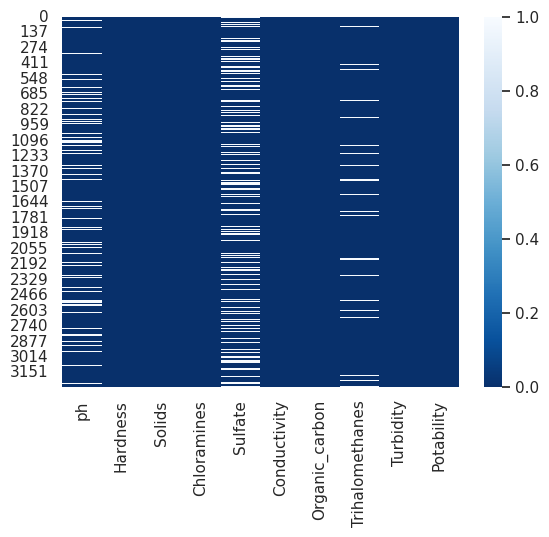

In [95]:

sns.heatmap(df.isnull(), cmap="Blues_r")

Notiamo che sono solo 3 le features con dei missing values: Sulfate, ph e Trihalomethanes

In [96]:
df.groupby('Potability')[['ph','Sulfate','Trihalomethanes']].median()
# le mediane calcolate separate per classe sono quasi identiche
# scelgo di non imputare usando le statistiche per classe perchè significherebbe usare la classe nel preprocessing, informazione non disponibile per le nuove istanze.
# Inoltre, dato che i valori mediani sono quasi identici, l'imputazione per classe non porterebbe alcun vantaggio.

,ph,Sulfate,Trihalomethanes
Potability,,,
0,7.035456,333.389426,66.542198
1,7.036752,331.838167,66.678214


In [97]:
df.groupby('Potability')[['ph','Sulfate','Trihalomethanes']].apply(lambda x: x.isnull().mean()*100).round(1)
# percentuale di mancanti per classe -> piu' corretto per valutare l'uniformita'
# i dati mancanti sono distribuiti in modo abbastanza uniforme, sono leggermente di più quelli di classe 0
# ma non si rischia di introdurre un bias sistematico verso una delle due classi

,ph,Sulfate,Trihalomethanes
Potability,,,
0,15.7,24.4,5.4
1,13.8,22.9,4.3


**Strategia di imputazione.**
I valori mancanti vengono imputati con la **mediana** di ciascuna colonna,
calcolata su tutte le righe senza distinzione di classe (mediana globale).
La mediana è preferita alla media perché più robusta rispetto agli outlier.

L'imputazione **non** viene applicata ora sul dataframe, ma inserita come primo
step della pipeline di ciascun modello (`SimpleImputer(strategy="median")`),
così da essere ricalcolata solo sul training di ogni fold durante la
cross-validation, evitando il data leakage sulle statistiche di imputazione.

### Pulizia Duplicati

In [98]:
print("Numero di istanze:", len(df))
df=df.drop_duplicates()
print("Numero di istanze senza duplicati:", len(df))
# provo a droppare le istanze duplicate ma mi accorgo che non ci sono

Numero di istanze: 3276
Numero di istanze senza duplicati: 3276


### Bilanciamento

In [99]:
# Distribuzione della classe
print(df['Potability'].value_counts(normalize=True).round(2))

ratio = df['Potability'].value_counts().max() / df['Potability'].value_counts().min()
print(f"\nRapporto di sbilanciamento: {ratio:.2f}:1")
print("Sbilanciamento lieve (< 1.5:1): bilanciamento non necessario.")

Potability
0    0.61
1    0.39
Name: proportion, dtype: float64

Rapporto di sbilanciamento: 1.56:1
Sbilanciamento lieve (< 1.5:1): bilanciamento non necessario.


###

# Modelli